<a href="https://colab.research.google.com/github/saurabh-nitj03/Major-Project/blob/main/updated_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3196/59313462.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
/tmp/ipykernel_3196/59313462.py:51: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)
/tmp/ipykernel_3196/59313462.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
/tmp/ipykernel_3196/59313462.py:51: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)
/tmp/ipykernel_3196/59313462.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffil


--- Round 1 ---
Client 1 training...
Client 2 training...
Client 3 training...
Client 4 training...

--- Round 2 ---
Client 1 training...
Client 2 training...
Client 3 training...
Client 4 training...

--- Round 3 ---
Client 1 training...
Client 2 training...
Client 3 training...
Client 4 training...

--- Round 4 ---
Client 1 training...
Client 2 training...
Client 3 training...
Client 4 training...

--- Round 5 ---
Client 1 training...
Client 2 training...
Client 3 training...
Client 4 training...
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== FINAL METRICS =====
Federated RMSE: 0.05679990125239626
Federated MAE: 0.03567875203063669
Federated R2: 0.811904474465273
Centralized RMSE: 0.05732034039365431


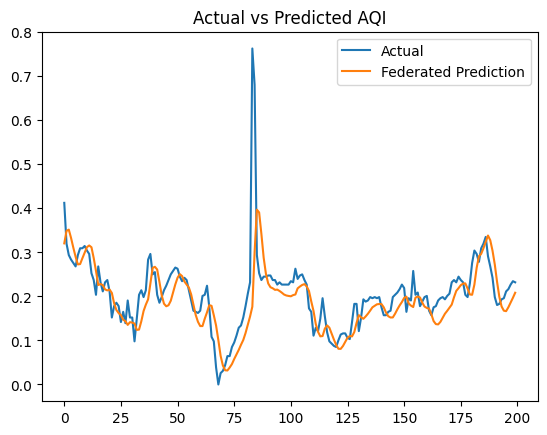

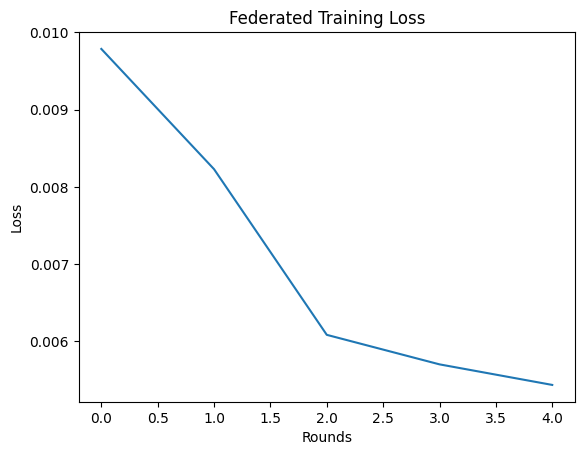

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


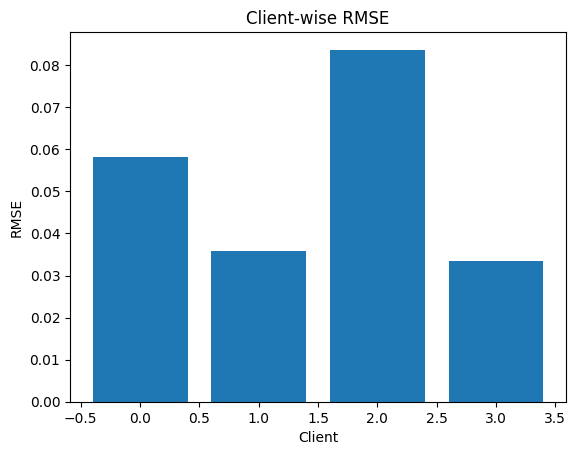

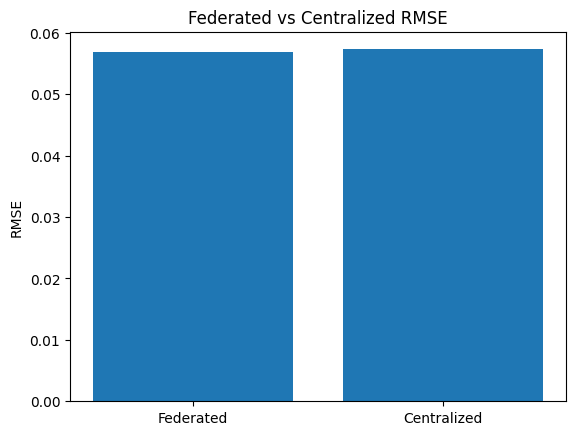

In [1]:
# =========================
# Privacy-Preserving AQI Prediction (FL + DP + Graphs)
# =========================

!pip install numpy pandas scikit-learn tensorflow matplotlib --quiet

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# =========================
# 1. LOAD DATA
# =========================

files = [
    "/content/airveda_data_june2025.csv",
    "/content/airveda_data_july2025.csv",
    "/content/airveda_data_aug 2025.csv",
    "/content/airveda_data_sept2025.csv"
]

clients_data = [pd.read_csv(f) for f in files]

SEQ_LEN = 10

# =========================
# 2. PREPROCESSING
# =========================

def preprocess(df):

    df = df.copy()
    df = df.sort_values("CreatedDate")

    pm25_col = [c for c in df.columns if c.startswith("PM2.5")][0]
    pm10_col = [c for c in df.columns if c.startswith("PM10")][0]
    temp_col = [c for c in df.columns if c.startswith("Temperature")][0]
    hum_col  = [c for c in df.columns if c.startswith("Humidity")][0]
    aqi_col  = [c for c in df.columns if c.startswith("AQI")][0]

    df = df[[pm25_col, pm10_col, temp_col, hum_col, aqi_col]]

    df = df.apply(pd.to_numeric, errors='coerce')

    df.fillna(method="ffill", inplace=True)
    df.fillna(method="bfill", inplace=True)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)

    X, y = [], []

    for i in range(len(scaled) - SEQ_LEN):
        X.append(scaled[i:i+SEQ_LEN, :-1])
        y.append(scaled[i+SEQ_LEN, -1])

    X = np.array(X)
    y = np.array(y)

    # 80-20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        shuffle=False
    )

    return X_train, X_test, y_train, y_test, scaler


clients_processed = [preprocess(df) for df in clients_data]

# =========================
# 3. MODEL
# =========================

def build_model(input_shape):

    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# =========================
# 4. DIFFERENTIAL PRIVACY NOISE
# =========================

def add_dp_noise(weights, noise_scale=0.01):

    noisy_weights = []

    for w in weights:
        noise = np.random.normal(0, noise_scale, w.shape)
        noisy_weights.append(w + noise)

    return noisy_weights


# =========================
# 5. FEDERATED TRAINING
# =========================

loss_history = []

def federated_train(clients_data, rounds=5, epochs=2):

    global_model = build_model((SEQ_LEN, 4))

    for r in range(rounds):

        print(f"\n--- Round {r+1} ---")

        client_weights = []

        for i, (X_train, X_test, y_train, y_test, _) in enumerate(clients_data):

            print(f"Client {i+1} training...")

            local_model = build_model((SEQ_LEN, 4))

            local_model.set_weights(global_model.get_weights())

            local_model.fit(
                X_train,
                y_train,
                epochs=epochs,
                verbose=0
            )

            weights = add_dp_noise(local_model.get_weights())

            client_weights.append(weights)

        # FedAvg aggregation
        new_weights = []

        for weights_list in zip(*client_weights):
            new_weights.append(np.mean(weights_list, axis=0))

        global_model.set_weights(new_weights)

        # Track loss on train data
        X_all = np.concatenate([c[0] for c in clients_data])
        y_all = np.concatenate([c[2] for c in clients_data])

        loss = global_model.evaluate(X_all, y_all, verbose=0)

        loss_history.append(loss)

    return global_model


global_model = federated_train(clients_processed)

# =========================
# 6. CENTRALIZED MODEL
# =========================

X_train_all = np.concatenate([c[0] for c in clients_processed])
y_train_all = np.concatenate([c[2] for c in clients_processed])

central_model = build_model((SEQ_LEN, 4))

central_model.fit(
    X_train_all,
    y_train_all,
    epochs=5,
    verbose=0
)

# =========================
# 7. EVALUATION
# =========================

X_test_all = np.concatenate([c[1] for c in clients_processed])
y_test_all = np.concatenate([c[3] for c in clients_processed])

y_pred_fed = global_model.predict(X_test_all)

y_pred_central = central_model.predict(X_test_all)

rmse_fed = np.sqrt(mean_squared_error(y_test_all, y_pred_fed))
mae_fed = mean_absolute_error(y_test_all, y_pred_fed)
r2_fed = r2_score(y_test_all, y_pred_fed)

rmse_central = np.sqrt(mean_squared_error(y_test_all, y_pred_central))

print("\n===== FINAL METRICS =====")

print("Federated RMSE:", rmse_fed)
print("Federated MAE:", mae_fed)
print("Federated R2:", r2_fed)

print("Centralized RMSE:", rmse_central)

# =========================
# 8. GRAPHS
# =========================

# Graph 1: Actual vs Predicted

plt.figure()

plt.plot(y_test_all[:200], label="Actual")

plt.plot(y_pred_fed[:200], label="Federated Prediction")

plt.legend()

plt.title("Actual vs Predicted AQI")

plt.show()


# Graph 2: Loss vs Rounds

plt.figure()

plt.plot(loss_history)

plt.title("Federated Training Loss")

plt.xlabel("Rounds")

plt.ylabel("Loss")

plt.show()


# Graph 3: Client-wise RMSE

client_rmse = []

for X_train, X_test, y_train, y_test, _ in clients_processed:

    pred = global_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    client_rmse.append(rmse)

plt.figure()

plt.bar(range(len(client_rmse)), client_rmse)

plt.title("Client-wise RMSE")

plt.xlabel("Client")

plt.ylabel("RMSE")

plt.show()


# Graph 4: Federated vs Centralized

plt.figure()

plt.bar(["Federated", "Centralized"], [rmse_fed, rmse_central])

plt.title("Federated vs Centralized RMSE")

plt.ylabel("RMSE")

plt.show()